# Predicción de Solubilidad Molecular con LSTM
**TFG — Representación Secuencial (SMILES)**

## 1. Instalación de dependencias

In [1]:
import sys
if 'rdkit' not in sys.modules:
  !pip install rdkit

# Install other dependencies
!pip install torch deepchem pandas numpy matplotlib

ERROR: Could not find a version that satisfies the requirement rdkit (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for rdkit


ERROR: Could not find a version that satisfies the requirement torch (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch


In [2]:
import sys
if 'rdkit' not in sys.modules:
  !pip install rdkit

ERROR: Could not find a version that satisfies the requirement rdkit (from versions: none)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for rdkit


## 2. Importaciones

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import deepchem as dc
from rdkit import Chem
import re

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Dispositivo: {device}')

No normalization for SPS. Feature removed!


No normalization for AvgIpc. Feature removed!


No normalization for NumAmideBonds. Feature removed!


No normalization for NumAtomStereoCenters. Feature removed!


No normalization for NumBridgeheadAtoms. Feature removed!


...

cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (C:\Users\marco\AppData\Local\Programs\Python\Python311\Lib\site-packages\deepchem\models\torch_models\__init__.py)


Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'


Skipped loading some Jax models, missing a dependency. No module named 'jax'


Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


PyTorch version: 2.5.1+cpu
Dispositivo: cpu


## 3. Carga del dataset ESOL con Scaffold Split

In [4]:
tasks, datasets, transformers = dc.molnet.load_delaney(
    featurizer='Raw',
    splitter='scaffold'
)

train_dataset, val_dataset, test_dataset = datasets

train_smiles = train_dataset.ids.tolist()
val_smiles   = val_dataset.ids.tolist()
test_smiles  = test_dataset.ids.tolist()

train_labels = train_dataset.y.flatten().tolist()
val_labels   = val_dataset.y.flatten().tolist()
test_labels  = test_dataset.y.flatten().tolist()

print(f'Train: {len(train_smiles)} | Val: {len(val_smiles)} | Test: {len(test_smiles)}')

Train: 902 | Val: 113 | Test: 113


In [5]:
# Canonicalización de SMILES usando RDKit
# Garantiza que cada molécula tiene una única representación estándar
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)

train_smiles = [canonicalize(s) for s in train_smiles]
val_smiles   = [canonicalize(s) for s in val_smiles]
test_smiles  = [canonicalize(s) for s in test_smiles]

# Eliminar posibles None (SMILES inválidos)
train_smiles = [s for s in train_smiles if s is not None]
val_smiles   = [s for s in val_smiles   if s is not None]
test_smiles  = [s for s in test_smiles  if s is not None]

print(f'Train: {len(train_smiles)} | Val: {len(val_smiles)} | Test: {len(test_smiles)}')
print(f'Ejemplo SMILES canonicalizado: {train_smiles[0]}')

Train: 902 | Val: 113 | Test: 113
Ejemplo SMILES canonicalizado: CC(C)=CCCC(C)=CC=O


In [6]:
mean_logs = np.mean(train_labels)
std_logs  = np.std(train_labels)

train_labels_norm = [(y - mean_logs) / std_logs for y in train_labels]
val_labels_norm   = [(y - mean_logs) / std_logs for y in val_labels]
test_labels_norm  = [(y - mean_logs) / std_logs for y in test_labels]

print(f'Media LogS (train): {mean_logs:.4f}')
print(f'Std LogS  (train):  {std_logs:.4f}')

Media LogS (train): -0.0000
Std LogS  (train):  1.0000


In [7]:
# Patrón de tokenización química
# Reconoce en orden de prioridad:
# 1. Átomos entre corchetes: [NH2], [OH], [nH], etc.
# 2. Átomos de dos letras: Br, Cl, Si, Se
# 3. Estereoquímica: @@, @
# 4. Anillos de dos dígitos: %10, %11, etc.
# 5. Átomos orgánicos de una letra: B, C, F, I, N, O, P, S (mayúsculas y minúsculas)
# 6. Cualquier otro carácter: =, #, (, ), 1, 2, etc.
PATTERN = r'(\[[^\]]+\]|Br|Cl|Si|Se|@@|@|%\d{2}|[BCFINOPSbcnops]|[^BCFINOPSbcnops])'

def build_vocab_chemical(smiles_list):
    vocab = {'<pad>': 0, '<unk>': 1}
    for smi in smiles_list:
        tokens = re.findall(PATTERN, smi)
        for token in tokens:
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

def tokenize_chemical(smiles, vocab, max_len):
    tokens_str = re.findall(PATTERN, smiles)
    tokens = [vocab.get(t, vocab['<unk>']) for t in tokens_str]
    tokens = tokens[:max_len]
    tokens += [vocab['<pad>']] * (max_len - len(tokens))
    return tokens

# Construir vocabulario solo con train
vocab   = build_vocab_chemical(train_smiles)
max_len = max(len(re.findall(PATTERN, s)) for s in train_smiles)

print(f'Tamaño vocabulario: {len(vocab)}')
print(f'Longitud máxima (tokens químicos): {max_len}')
print(f'Vocabulario: {list(vocab.keys())}')

Tamaño vocabulario: 32
Longitud máxima (tokens químicos): 97
Vocabulario: ['<pad>', '<unk>', 'C', '(', ')', '=', 'O', 'Cl', 'P', 'S', 'I', '#', 'Br', 'N', '[N+]', '[O-]', '/', '\\', 'F', 'c', '1', '-', '2', '3', '4', 'n', '[nH]', 'o', 's', '5', '6', '7']


In [8]:
class SMILESDataset(Dataset):
    def __init__(self, smiles_list, labels, vocab, max_len):
        self.smiles_list = smiles_list
        self.labels      = labels
        self.vocab       = vocab
        self.max_len     = max_len

    def __len__(self):
        return len(self.smiles_list)

    def __getitem__(self, idx):
        tokens = tokenize_chemical(self.smiles_list[idx], self.vocab, self.max_len)
        x = torch.tensor(tokens, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float)
        return x, y

BATCH_SIZE = 32

train_ds = SMILESDataset(train_smiles, train_labels_norm, vocab, max_len)
val_ds   = SMILESDataset(val_smiles,   val_labels_norm,   vocab, max_len)
test_ds  = SMILESDataset(test_smiles,  test_labels_norm,  vocab, max_len)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'Batches en train: {len(train_loader)}')

Batches en train: 29


In [9]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128,
                 num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x_reversed = torch.flip(x, dims=[1])
        emb = self.embedding(x_reversed)
        _, (h_n, _) = self.lstm(emb)
        h_last = h_n[-1]
        out = self.fc(h_last)
        return out.squeeze(1)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * len(y)
    return np.sqrt(total_loss / len(loader.dataset))

print('Modelo y funciones definidos correctamente.')

Modelo y funciones definidos correctamente.


## 8. Grid Search de hiperparámetros

Búsqueda exhaustiva sobre 27 combinaciones. Cada modelo se entrena
un máximo de 50 épocas con early stopping (paciencia = 10).

In [10]:
# param_grid = {
#     'hidden_size': [64, 128, 256],
#     'num_layers':  [1, 2, 3],
#     'dropout':     [0.1, 0.2, 0.3]
# }

# combinations = list(product(
#     param_grid['hidden_size'],
#     param_grid['num_layers'],
#     param_grid['dropout']
# ))

# print(f'Total combinaciones: {len(combinations)}')
# print('-' * 55)

# results = []

# for hidden_size, num_layers, dropout in combinations:

#     model_gs     = LSTMModel(
#         vocab_size=len(vocab),
#         embed_dim=64,
#         hidden_size=hidden_size,
#         num_layers=num_layers,
#         dropout=dropout
#     ).to(device)
#     optimizer_gs = torch.optim.Adam(model_gs.parameters(), lr=0.001)
#     criterion_gs = nn.MSELoss()

#     best_val         = float('inf')
#     patience_counter = 0

#     for epoch in range(50):
#         train_epoch(model_gs, train_loader, optimizer_gs, criterion_gs, device)
#         val_rmse = evaluate(model_gs, val_loader, criterion_gs, device)

#         if val_rmse < best_val:
#             best_val         = val_rmse
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= 10:
#             break

#     results.append({
#         'hidden_size': hidden_size,
#         'num_layers':  num_layers,
#         'dropout':     dropout,
#         'val_rmse':    best_val
#     })

#     print(f'hidden={hidden_size:3d} | layers={num_layers} | '
#           f'dropout={dropout} | Val RMSE: {best_val:.4f}')

# # Resultados ordenados
# results_df = pd.DataFrame(results).sort_values('val_rmse').reset_index(drop=True)
# print('\n--- Top 5 combinaciones ---')
# print(results_df.head())

# best_params = results_df.iloc[0]
# BEST_HIDDEN  = int(best_params.hidden_size)
# BEST_LAYERS  = int(best_params.num_layers)
# BEST_DROPOUT = best_params.dropout

# print(f'\nMejor configuración:')
# print(f'  hidden_size: {BEST_HIDDEN}')
# print(f'  num_layers:  {BEST_LAYERS}')
# print(f'  dropout:     {BEST_DROPOUT}')
# print(f'  Val RMSE:    {best_params.val_rmse:.4f}')

Scaffold Split result

In [11]:
BEST_HIDDEN=256
BEST_LAYERS=3
BEST_DROPOUT=0.1


## 9. Entrenamiento final con los mejores hiperparámetros

In [12]:
EPOCHS   = 100
LR       = 0.001
PATIENCE = 10

model = LSTMModel(
    vocab_size=len(vocab),
    embed_dim=64,
    hidden_size=BEST_HIDDEN,
    num_layers=BEST_LAYERS,
    dropout=BEST_DROPOUT
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')

best_val_rmse    = float('inf')
best_state       = None
patience_counter = 0
history          = {'train_rmse': [], 'val_rmse': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_rmse   = evaluate(model, val_loader, criterion, device)
    train_rmse = np.sqrt(train_loss)

    history['train_rmse'].append(train_rmse)
    history['val_rmse'].append(val_rmse)

    if val_rmse < best_val_rmse:
        best_val_rmse    = val_rmse
        best_state       = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f'Época {epoch:3d} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping en época {epoch}')
        break

print(f'\nMejor Val RMSE (normalizado): {best_val_rmse:.4f}')

Parámetros entrenables: 1,400,961

Época  10 | Train RMSE: 0.3663 | Val RMSE: 0.5486


Época  20 | Train RMSE: 0.2578 | Val RMSE: 0.5040


Época  30 | Train RMSE: 0.2188 | Val RMSE: 0.4688


Época  40 | Train RMSE: 0.2289 | Val RMSE: 0.4217



Early stopping en época 45

Mejor Val RMSE (normalizado): 0.4020


## 10. Evaluación final sobre el conjunto de test

In [13]:
model.load_state_dict(best_state)
test_rmse_norm = evaluate(model, test_loader, criterion, device)
test_rmse      = test_rmse_norm * std_logs

print(f'RMSE en test (normalizado): {test_rmse_norm:.4f}')
print(f'RMSE en test (log mol/L):   {test_rmse:.4f}')

RMSE en test (normalizado): 0.4651
RMSE en test (log mol/L):   0.4651


## 11. Curva de aprendizaje

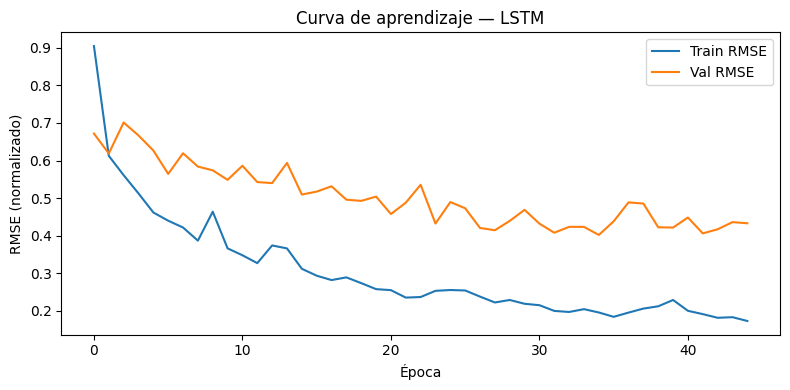

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_rmse'], label='Train RMSE')
plt.plot(history['val_rmse'],   label='Val RMSE')
plt.xlabel('Época')
plt.ylabel('RMSE (normalizado)')
plt.title('Curva de aprendizaje — LSTM')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_scaffold_learning_curve.png', dpi=150)
plt.show()

## 12. Resumen de resultados

In [15]:
print('=' * 45)
print('RESUMEN — MODELO LSTM')
print('=' * 45)
print(f'Embedding dim:  64')
print(f'Hidden size:    {BEST_HIDDEN}')
print(f'Num layers:     {BEST_LAYERS}')
print(f'Dropout:        {BEST_DROPOUT}')
print(f'Optimizador:    Adam (lr={LR})')
print(f'Parámetros:     {total_params:,}')
print(f'Val RMSE:       {best_val_rmse * std_logs:.4f} log mol/L')
print(f'Test RMSE:      {test_rmse:.4f} log mol/L')
print('=' * 45)

RESUMEN — MODELO LSTM
Embedding dim:  64
Hidden size:    256
Num layers:     3
Dropout:        0.1
Optimizador:    Adam (lr=0.001)
Parámetros:     1,400,961
Val RMSE:       0.4020 log mol/L
Test RMSE:      0.4651 log mol/L


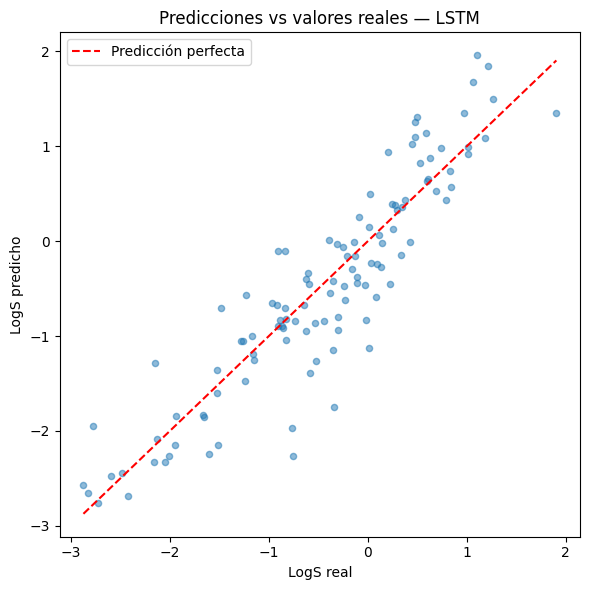

Media predicciones: -0.486
Std predicciones:   1.125
Media valores reales: -0.450
Std valores reales:   1.026


In [16]:
# Diagnóstico — ver qué está prediciendo el modelo
model.eval()
preds = []
trues = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = model(x).cpu().numpy()
        preds.extend(pred)
        trues.extend(y.numpy())

preds = np.array(preds) * std_logs + mean_logs  # desnormalizar
trues = np.array(trues) * std_logs + mean_logs  # desnormalizar

plt.figure(figsize=(6, 6))
plt.scatter(trues, preds, alpha=0.5, s=20)
plt.plot([min(trues), max(trues)], [min(trues), max(trues)],
         'r--', label='Predicción perfecta')
plt.xlabel('LogS real')
plt.ylabel('LogS predicho')
plt.title('Predicciones vs valores reales — LSTM')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Media predicciones: {preds.mean():.3f}')
print(f'Std predicciones:   {preds.std():.3f}')
print(f'Media valores reales: {trues.mean():.3f}')
print(f'Std valores reales:   {trues.std():.3f}')